# A thermodynamic surface you can rotate

An equation of state ties together the pressure, volume and temperature of a substance. Written as $P(V, T)$ it is a *surface*, and a surprising amount of thermodynamics is easier to see than to derive: isotherms are slices of the surface at constant $T$, the critical point is where a fold in the surface flattens out, and the two-phase region is the part of the surface that nature replaces with a flat tie line. James Clerk Maxwell famously sculpted such a surface in plaster and sent a copy to Gibbs.

Here you can rotate the surface yourself. Drag the plot to turn it; with the pointer over the plot, scroll to zoom.

*Adapted from:* Guasco, T. L.; Pfalzgraff, W. C.; Stokes, G. Y.; Posta, F.; Neshyba, S. P. Teaching Thermodynamics with Geometry and Computational Guided Inquiry. In *Engaging Students in Physical Chemistry, Volume 2*; ACS Symposium Series 1515; American Chemical Society: Washington, DC, 2025; pp 131–155. [https://doi.org/10.1021/bk-2025-1515.ch010](https://doi.org/10.1021/bk-2025-1515.ch010)

In [1]:
%pip install -q ipympl

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

## The ideal gas

$$P = \frac{RT}{V_m}$$

The grid below covers molar volumes from 80 to 1000 cm$^3$/mol and temperatures from 250 to 350 K.

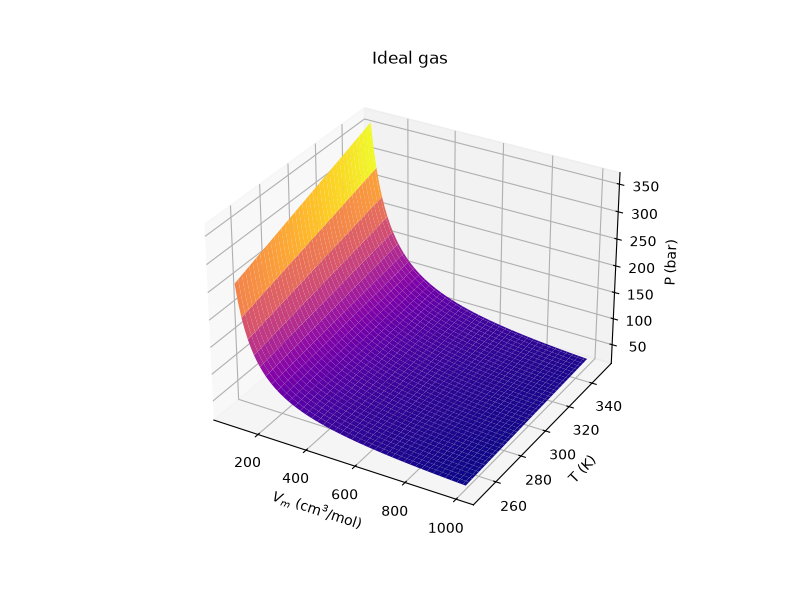

In [4]:
R = 8.314                            # J/(mol K)
Vm = np.linspace(8e-5, 1e-3, 80)     # molar volume, m^3/mol
T = np.linspace(250, 350, 80)        # K
Vgrid, Tgrid = np.meshgrid(Vm, T)

P_ideal = R*Tgrid/Vgrid / 1e5        # bar

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(Vgrid*1e6, Tgrid, P_ideal, cmap=cm.plasma)
ax.set_xlabel('$V_m$ (cm$^3$/mol)'); ax.set_ylabel('T (K)'); ax.set_zlabel('P (bar)')
ax.set_title('Ideal gas')
fig.canvas.capture_scroll = True     # scroll zooms the plot instead of the page

## A van der Waals gas

$$P = \frac{RT}{V_m - b} - \frac{a}{V_m^2}$$

with the constants for carbon dioxide, $a = 0.364\ \mathrm{Pa\,m^6\,mol^{-2}}$ and $b = 4.27 \times 10^{-5}\ \mathrm{m^3\,mol^{-1}}$. The critical temperature of this model is $T_c = 8a/(27Rb) \approx 304$ K. Three isotherms are drawn on the surface: one below $T_c$, one at it, one above. Rotate until you are looking along the temperature axis and the isotherms become the familiar $P$–$V$ curves; the one below $T_c$ has the loop that signals liquid–vapor coexistence.

In [6]:
a, b = 0.364, 4.27e-5                 # CO2
Tc = 8*a/(27*R*b)                     # critical temperature of the model

P_vdw = (R*Tgrid/(Vgrid - b) - a/Vgrid**2) / 1e5   # bar

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(Vgrid*1e6, Tgrid, P_vdw, cmap=cm.viridis, alpha=0.85)
for T_iso in (280, Tc, 330):
    P_iso = (R*T_iso/(Vm - b) - a/Vm**2) / 1e5
    ax.plot(Vm*1e6, np.full_like(Vm, T_iso), P_iso, 'k', linewidth=2)
ax.set_xlabel('$V_m$ (cm$^3$/mol)'); ax.set_ylabel('T (K)'); ax.set_zlabel('P (bar)')
ax.set_title(f'van der Waals gas (CO$_2$), $T_c$ = {Tc:.0f} K')
fig.canvas.capture_scroll = True

van der Waals critical temperature for CO2: 304 K


## Your turn

Change the substance by editing `a` and `b` in the cell above and running it again. Nitrogen: $a = 0.137$, $b = 3.87 \times 10^{-5}$. Water: $a = 0.554$, $b = 3.05 \times 10^{-5}$ (same units as above). Then widen the temperature range until the fold in the surface disappears.

Your edits are saved in your browser. Nothing you do here changes the site for anyone else.